## Importy 

In [ ]:
import pandas as pd 
from features import extract_features
from models import UNet, predict_masks, preprocess_image, test_model
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from dataset import train_loader, val_loader, test_loader
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib

## UNet Model 

In [164]:
model = UNet(in_channels=3, out_channels=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models\unet\unet_cell_nucleus_0208.pth"))
model.to(device)

UNet(
  (encoder1): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder2): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder3): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): Re

# TRAIN I TEST SET

In [165]:
df1 = pd.read_csv(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\features_train.csv')
df2 = pd.read_csv(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\features_val.csv')
df_test = pd.read_csv(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\features_test.csv')
df_train = pd.concat([df1, df2], ignore_index=True)


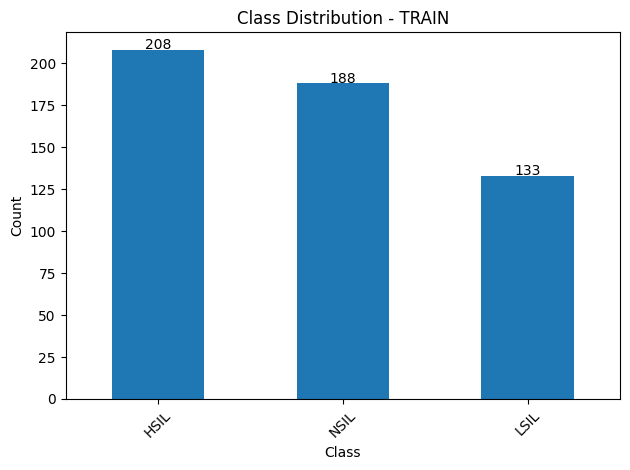

In [166]:
df_train = df_train[df_train['N'] != 0]
df_train['class'].value_counts().plot(kind='bar')
plt.title('Class Distribution - TRAIN')
plt.xlabel('Class')
plt.ylabel('Count')
for i, v in enumerate(df_train['class'].value_counts()):
    plt.text(i, v + 0.3, str(v), ha='center')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

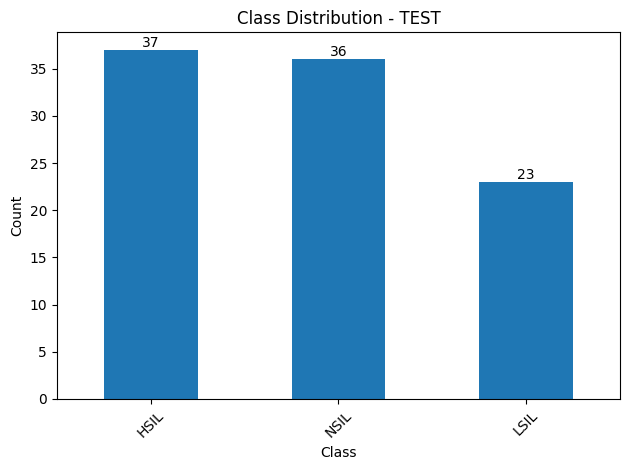

In [167]:
df_test = df_test[df_test['N'] != 0]
df_test['class'].value_counts().plot(kind='bar')
plt.title('Class Distribution - TEST')
plt.xlabel('Class')
plt.ylabel('Count')
for i, v in enumerate(df_test['class'].value_counts()):
    plt.text(i, v + 0.3, str(v), ha='center')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [168]:
df_train.head()

,N,C,NCr,Np,Cp,NCp,MinA,MinAr,MaxA,MaxAr,...,NSol,CSol,NCs,EqN,EqC,NCEq,OrN,OrC,NCOr,class
0,6378,14898,0.428111,396.190905,594.274166,0.666680,61.273155,0.703130,149.482440,0.606072,...,0.950168,0.987997,0.961711,90.115048,137.726986,0.654302,-0.228032,-0.097290,2.343838,HSIL
1,6557,12602,0.520314,412.374670,492.801077,0.836797,62.680798,0.716702,153.808322,0.744296,...,0.943385,1.000556,0.942861,91.370847,126.670299,0.721328,5.439876,-4829.849982,-0.001126,HSIL
2,1353,3288,0.411496,175.396968,298.409161,0.587773,23.428492,0.654546,76.295478,0.613176,...,1.009701,0.991706,1.018146,41.505338,64.702485,0.641480,-0.342323,-0.492934,0.694461,HSIL
3,1357,2554,0.531323,180.066016,233.078207,0.772556,23.426064,0.697542,74.652528,0.759039,...,0.991959,0.999609,0.992347,41.566646,57.025028,0.728919,-3.104588,-9.747040,0.318516,HSIL
4,14851,41568,0.357270,604.256921,913.879285,0.661200,117.153717,0.648408,204.658252,0.626758,...,0.922652,0.979927,0.941552,137.509565,230.056561,0.597721,-2.107840,5.487555,-0.384113,HSIL


In [169]:
df_train.shape

(529, 26)

In [170]:
X_train, y_train = df_train.drop(columns=["class"]), df_train["class"]
X_test,  y_test  = df_test.drop(columns=["class"]),  df_test["class"]

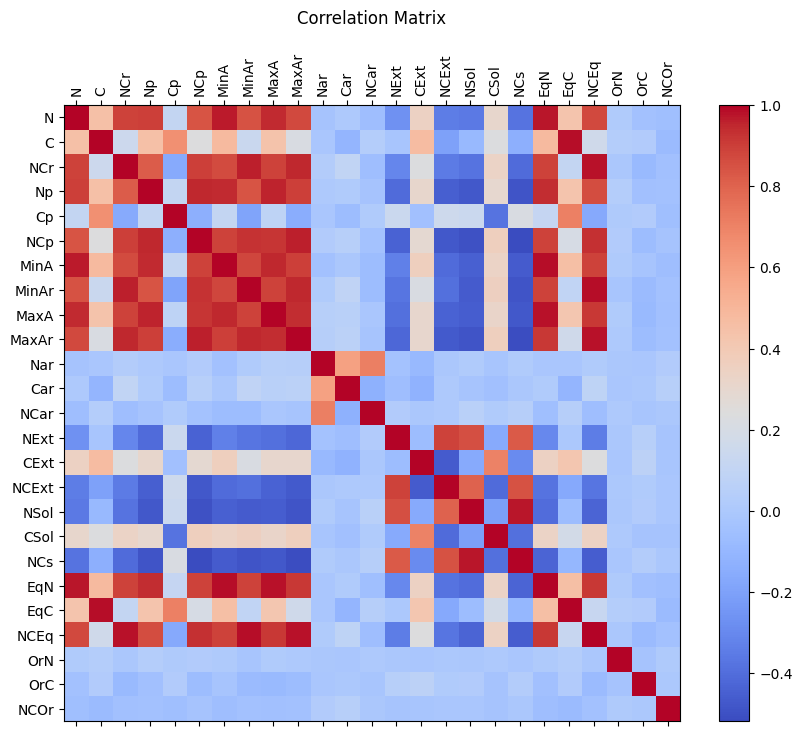

In [171]:
corr = df_train[['N', 'C', 'NCr', 'Np', 'Cp', 'NCp', 'MinA', 'MinAr', 'MaxA', 'MaxAr',
       'Nar', 'Car', 'NCar', 'NExt', 'CExt', 'NCExt', 'NSol', 'CSol', 'NCs',
       'EqN', 'EqC', 'NCEq', 'OrN', 'OrC', 'NCOr']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr, cmap="coolwarm")  # możesz zmienić cmap
fig.colorbar(cax)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

plt.title("Correlation Matrix", pad=20)
plt.show()

## Uczenie z KFold i GridSearch (scalar i smote w pipeline - aby nie było wycieku danych)

In [172]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_svm = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", SVC(probability=True, random_state=42))
])

pipe_mlp = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("clf", MLPClassifier(solver="adam", random_state=42, max_iter=1000))
])

pipe_rf = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", RandomForestClassifier(random_state=42))
])

pipe_xgb = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", XGBClassifier(
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ))
])

pipe_lgbm = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", LGBMClassifier(random_state=42))
])

pipelines = {
    "SVM": pipe_svm,
    "NeuralNet": pipe_mlp,
    "RandomForest": pipe_rf,
    "XGBoost": pipe_xgb,
    "LightGBM": pipe_lgbm
}

param_grids = {
    "SVM": {
        "clf__C": [0.01, 0.1, 1, 10, 100],
        "clf__gamma": ["scale", 1, 0.1, 0.01, 0.001],
        "clf__kernel": ["rbf", "poly", "sigmoid"]
    },
    "NeuralNet": {
        "clf__hidden_layer_sizes": [(32, 16), (64, 32), (128, 64), (128, 64, 32)],
        "clf__activation": ["relu", "tanh", "logistic"],
        "clf__alpha": [1e-4, 1e-3, 1e-2],
        "clf__learning_rate_init": [1e-3, 1e-2]
    },
    "RandomForest": {
        "clf__n_estimators": [100, 200, 500],
        "clf__max_depth": [None, 10, 20, 30],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 4]
    },
    "XGBoost": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [3, 5, 7],
        "clf__learning_rate": [0.01, 0.1, 0.2],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0]
        # Alternatywa dla SMOTE: clf__scale_pos_weight (gdy duża nierównowaga)
    },
    "LightGBM": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [-1, 10, 20],
        "clf__learning_rate": [0.01, 0.1, 0.2],
        "clf__num_leaves": [31, 50, 100],
        "clf__subsample": [0.8, 1.0],
        "clf__colsample_bytree": [0.8, 1.0]
    }
}

In [173]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_train) 

y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

In [174]:
results = []
for name, pipe in pipelines.items():
    print(f"\n=== GridSearch dla {name} ===")
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=2,
        refit=True  
    )
    grid.fit(X_train, y_train_enc)

    best_model = grid.best_estimator_
    best_params = grid.best_params_

    y_test_pred_enc = best_model.predict(X_test)
    y_test_pred = le.inverse_transform(y_test_pred_enc)

    results.append({
        "Model": name,
        "Split": "Test",
        "Best_Params": best_params,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_test, y_test_pred, average="macro", zero_division=0),
        "F1": f1_score(y_test, y_test_pred, average="macro", zero_division=0)
    })

    joblib.dump({"model": best_model, "label_encoder": le}, f"models/best_model_{name}3.pkl")


results = pd.DataFrame(results).sort_values("F1", ascending=False)
print("\n=== Results ===")
print(results)



=== GridSearch dla SVM ===
Fitting 5 folds for each of 75 candidates, totalling 375 fits

=== GridSearch dla NeuralNet ===
Fitting 5 folds for each of 72 candidates, totalling 360 fits


c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



=== GridSearch dla RandomForest ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits

=== GridSearch dla XGBoost ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits


c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:47:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== GridSearch dla LightGBM ===
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000417 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5216
[LightGBM] [Info] Number of data points in the train set: 624, number of used features: 25
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

In [175]:
results.to_csv("classification_results.csv", index=False)

In [176]:
results

,Model,Split,Best_Params,Accuracy,Precision,Recall,F1
4,LightGBM,Test,"{'clf__colsample_bytree': 0.8, 'clf__learning_...",0.843750,0.828132,0.831462,0.829415
3,XGBoost,Test,"{'clf__colsample_bytree': 1.0, 'clf__learning_...",0.802083,0.785254,0.789692,0.785724
1,NeuralNet,Test,"{'clf__activation': 'logistic', 'clf__alpha': ...",0.791667,0.799178,0.796634,0.785582
0,SVM,Test,"{'clf__C': 10, 'clf__gamma': 'scale', 'clf__ke...",0.760417,0.754444,0.753155,0.749791
2,RandomForest,Test,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.760417,0.749022,0.753406,0.746523


In [177]:

def predict(pipe, label_encoder, input_features):
    feature_names = ['N', 'C', 'NCr', 'Np', 'Cp', 'NCp', 'MinA', 'MinAr', 'MaxA', 'MaxAr', 'Nar', 'Car', 'NCar', 'NExt', 'CExt', 'NCExt', 'NSol', 'CSol', 'NCs', 'EqN', 'EqC', 'NCEq', 'OrN', 'OrC', 'NCOr']
    try:
        X_new = pd.DataFrame([[input_features[feat] for feat in feature_names]], columns=feature_names)
    except KeyError as e:
        raise ValueError(f"Brakuje cechy w słowniku: {e}")

    y_pred_encoded = pipe.predict(X_new)
    predicted_class = label_encoder.inverse_transform(y_pred_encoded)[0]

    return predicted_class


In [180]:
classifier = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models\best_model_LightGBM3.pkl")
label_encoder = classifier["label_encoder"]
pipe = classifier["model"]


In [181]:
pil_image, input_tensor = preprocess_image(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\test\LSIL\1b_1_aug0.png')
predicted_masks = predict_masks(model, input_tensor, device, threshold_nuclei=0.2, threshold_cell=0.5)
cell_mask = predicted_masks[0]
nucleus_mask = predicted_masks[1]
features = extract_features(nucleus_mask, cell_mask)
print("Extracted features:", features)
predicted_class = predict(pipe, label_encoder, input_features=features)
print("Predicted class:", predicted_class)

Extracted features: {'N': np.uint64(7086), 'C': np.uint64(37887), 'NCr': np.float64(0.18702985192810198), 'Np': 324.29141092300415, 'Cp': 858.7493418455124, 'NCp': 0.377632208982052, 'MinA': 80.95867156982422, 'MinAr': 0.4499491341181842, 'MaxA': np.float64(108.57716150277645), 'MaxAr': np.float64(0.38110154626713943), 'Nar': 0.9393939393939394, 'Car': 0.92578125, 'NCar': 1.0147040020457743, 'NExt': np.float64(0.7696318018898664), 'CExt': np.float64(0.6244560917721519), 'NCExt': np.float64(1.2324834556513309), 'NSol': np.float64(1.038698328935796), 'CSol': np.float64(0.9335797449639623), 'NCs': np.float64(1.1125973271580474), 'EqN': np.float64(94.98513259449273), 'EqC': np.float64(219.63430203722987), 'NCEq': np.float64(0.4324694809210264), 'OrN': np.float64(-7.186521930228615), 'OrC': np.float64(-10.375873882964356), 'NCOr': np.float64(0.6926184735174756)}
Predicted class: LSIL


In [182]:
pil_image, input_tensor = preprocess_image(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\test\NSIL\22c_1.bmp')
predicted_masks = predict_masks(model, input_tensor, device, threshold_nuclei=0.2, threshold_cell=0.5)
cell_mask = predicted_masks[0]
nucleus_mask = predicted_masks[1]
features = extract_features(nucleus_mask, cell_mask)
print("Extracted features:", features)
predicted_class = predict(pipe, label_encoder, input_features=features)
print("Predicted class:", predicted_class)

Extracted features: {'N': np.uint64(451), 'C': np.uint64(28510), 'NCr': np.float64(0.015819010873377764), 'Np': 77.69848418235779, 'Cp': 818.2640600204468, 'NCp': 0.09495526930562764, 'MinA': 20.0, 'MinAr': 0.10188354593791907, 'MaxA': np.float64(26.92582403567252), 'MaxAr': np.float64(0.12398212734070096), 'Nar': 1.2380952380952381, 'Car': 0.9801980198019802, 'NCar': 1.263107263107263, 'NExt': np.float64(0.826007326007326), 'CExt': np.float64(0.7128212821282128), 'NCExt': np.float64(1.1587860052960017), 'NSol': np.float64(1.0636792452830188), 'CSol': np.float64(0.9230569990125136), 'NCs': np.float64(1.1523440550485429), 'EqN': np.float64(23.96311821686732), 'EqC': np.float64(190.52574477062015), 'NCEq': np.float64(0.125773649360181), 'OrN': np.float64(0.6174438538173612), 'OrC': np.float64(-1.9189982949348015), 'NCOr': np.float64(-0.32175320605917423)}
Predicted class: NSIL


In [183]:
pil_image, input_tensor = preprocess_image(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\data_single_cropped3\val\HSIL\2b_1.jpg')
predicted_masks = predict_masks(model, input_tensor, device, threshold_nuclei=0.2, threshold_cell=0.5)
cell_mask = predicted_masks[0]
nucleus_mask = predicted_masks[1]
features = extract_features(nucleus_mask, cell_mask)
print("Extracted features:", features)
predicted_class = predict(pipe, label_encoder, input_features=features)
print("Predicted class:", predicted_class)

Extracted features: {'N': np.uint64(17306), 'C': np.uint64(44893), 'NCr': np.float64(0.38549439779030137), 'Np': 659.2518683671951, 'Cp': 814.4823170900345, 'NCp': 0.8094121315273688, 'MinA': 126.82635498046875, 'MinAr': 0.5467992506625384, 'MaxA': np.float64(194.94101672044292), 'MaxAr': np.float64(0.683986725869078), 'Nar': 0.7864583333333334, 'Car': 0.995850622406639, 'NCar': 0.7897352430555555, 'NExt': np.float64(0.5969232891832229), 'CExt': np.float64(0.77615836791148), 'NCExt': np.float64(0.7690740883068098), 'NSol': np.float64(0.9169227508742185), 'CSol': np.float64(1.0004568499637863), 'NCs': np.float64(0.916504046033978), 'EqN': np.float64(148.4408419579555), 'EqC': np.float64(239.0806200464514), 'NCEq': np.float64(0.6208819515739699), 'OrN': np.float64(0.7013970988453097), 'OrC': np.float64(14.2163906145489), 'NCOr': np.float64(0.04933721349267848)}
Predicted class: HSIL


In [184]:
features = {'N': np.uint64(4439), 'C': np.uint64(262118), 'NCr': np.float64(0.016935120823445927), 'Np': 277.49747383594513, 'Cp': 2309.796025156975, 'NCp': 0.12013938495590158, 'MinA': 73.0, 'MinAr': 0.12784588441331, 'MaxA': np.float64(83.35466393669883), 'MaxAr': np.float64(0.12441202480634707), 'Nar': 1.0405405405405406, 'Car': 1.0367132867132867, 'NCar': 1.0036917187001504, 'NExt': np.float64(0.7790452790452791), 'CExt': np.float64(0.772762650502954), 'NCExt': np.float64(1.008130088246677), 'NSol': np.float64(0.9855683836589698), 'CSol': np.float64(0.9516233848745476), 'NCs': np.float64(1.0356706227736272), 'EqN': np.float64(75.17918820444517), 'EqC': np.float64(577.7014825901795), 'NCEq': np.float64(0.13013500998365476), 'OrN': np.float64(1.446102061602086), 'OrC': np.float64(4.140502931377116), 'NCOr': np.float64(0.349257586715708)}
predicted_class = predict(pipe, label_encoder, input_features=features)
print("Predicted class:", predicted_class)

Predicted class: NSIL


In [185]:
from sklearn.calibration import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

def plot_multiclass_roc(model, label_encoder, classes, X_test, y_test, title="ROC Curve"):
    y_proba = model.predict_proba(X_test)  
    y_true_enc = label_encoder.transform(y_test)               
    plt.figure(figsize=(8, 6))
    n_classes = len(classes)

    y_true_bin = label_binarize(y_true_enc, classes=np.arange(n_classes))

    macro_auc = roc_auc_score(y_true_bin, y_proba, multi_class="ovr", average="macro")
    print(f"Macro AUC (OvR): {macro_auc:.4f}")

    plt.figure(figsize=(8, 6))
    for i, cls in enumerate(classes):
        if y_true_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        cls_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} (AUC = {cls_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, classes, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
    plt.title(title)
    plt.show()


## NN

In [186]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models\best_model_NeuralNet3.pkl")

In [187]:
y_test_pred = model_class["model"].predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred)
label_encoder = model_class["label_encoder"]
classes = list(label_encoder.classes_)

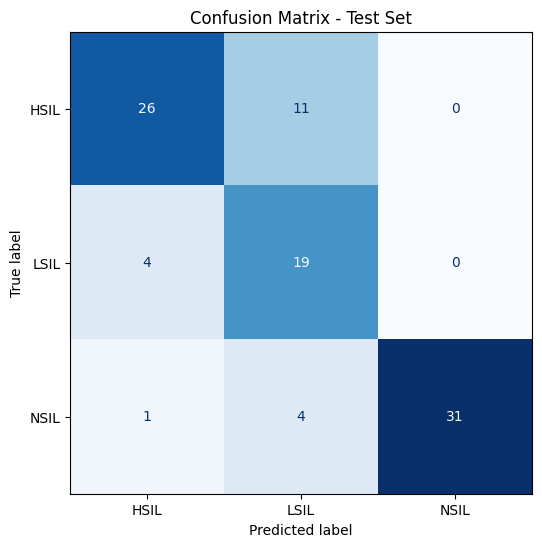

In [188]:
plot_confusion_matrix(y_test, y_test_pred, classes, title="Confusion Matrix - Test Set")

Macro AUC (OvR): 0.9447


<Figure size 800x600 with 0 Axes>

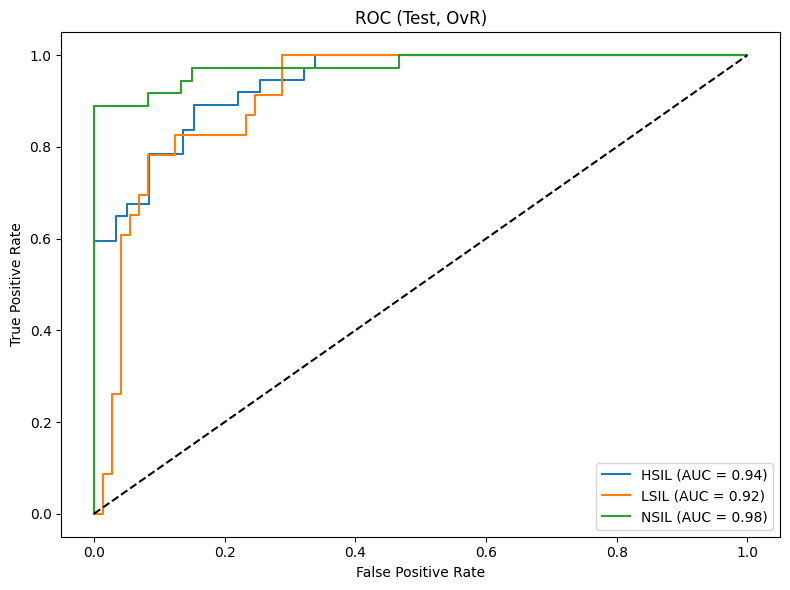

In [189]:
plot_multiclass_roc(model_class['model'], model_class["label_encoder"], classes, X_test, y_test, title="ROC (Test, OvR)")


## XGBOOST

In [190]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models\best_model_XGBoost3.pkl")


In [191]:
y_test_pred = model_class["model"].predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred)
label_encoder = model_class["label_encoder"]
classes = list(label_encoder.classes_)

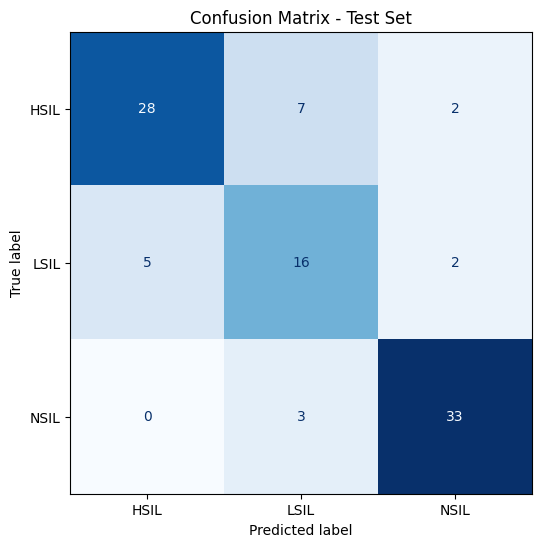

In [192]:
plot_confusion_matrix(y_test, y_test_pred, classes, title="Confusion Matrix - Test Set")

Macro AUC (OvR): 0.9420


<Figure size 800x600 with 0 Axes>

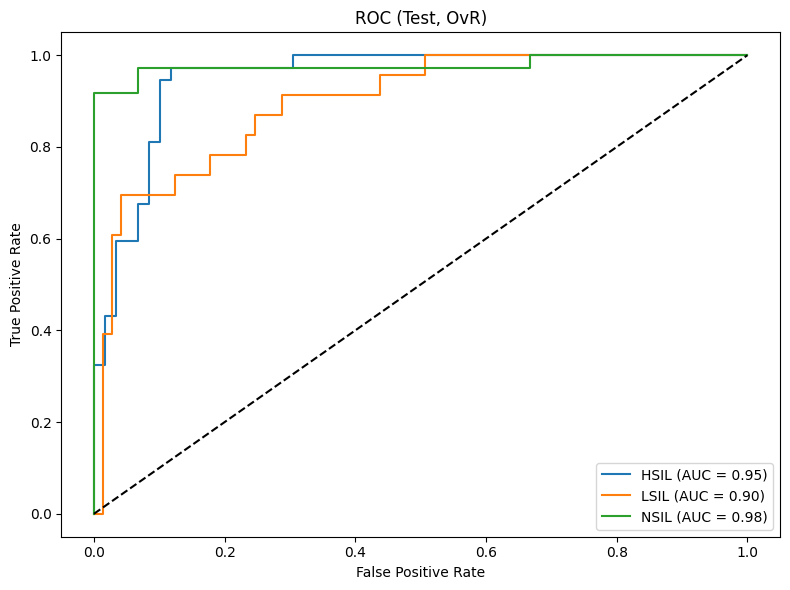

In [193]:
plot_multiclass_roc(model_class['model'], model_class["label_encoder"], classes, X_test, y_test, title="ROC (Test, OvR)")

## LIGHT GBM

In [ ]:
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models\best_model_LightGBM3.pkl")

In [195]:
y_test_pred = model_class["model"].predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred)
label_encoder = model_class["label_encoder"]
classes = list(label_encoder.classes_)

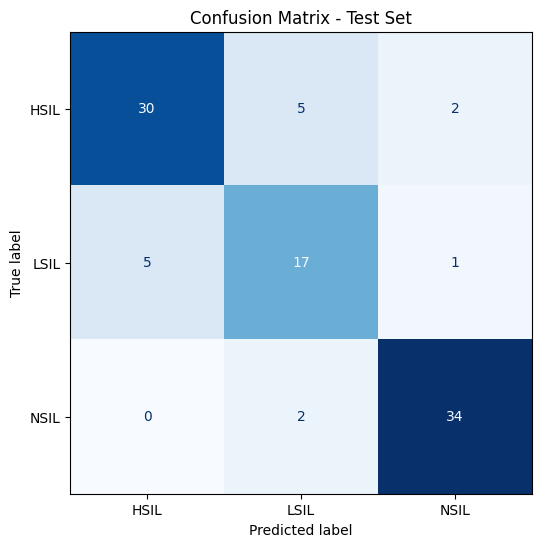

In [196]:
plot_confusion_matrix(y_test, y_test_pred, classes, title="Confusion Matrix - Test Set")

Macro AUC (OvR): 0.9314


<Figure size 800x600 with 0 Axes>

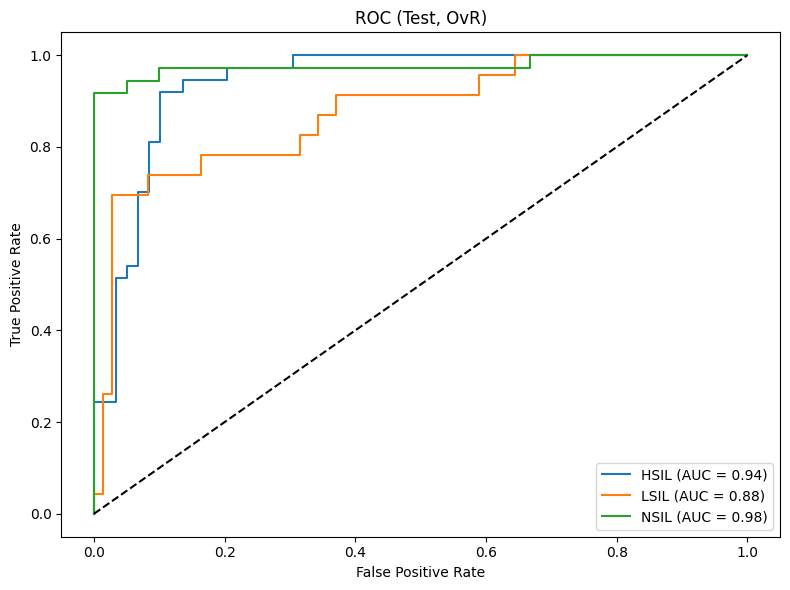

In [197]:
plot_multiclass_roc(model_class['model'], model_class["label_encoder"], classes, X_test, y_test, title="ROC (Test, OvR)")

## SHAP dla LIGHTgbm

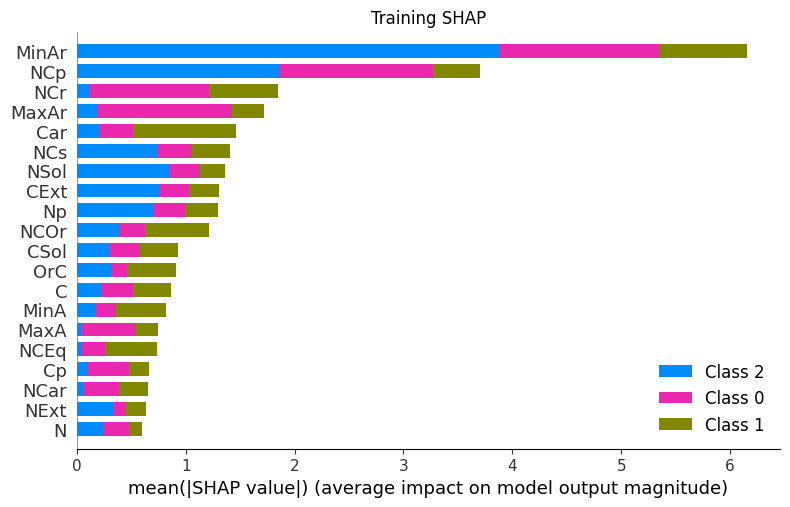

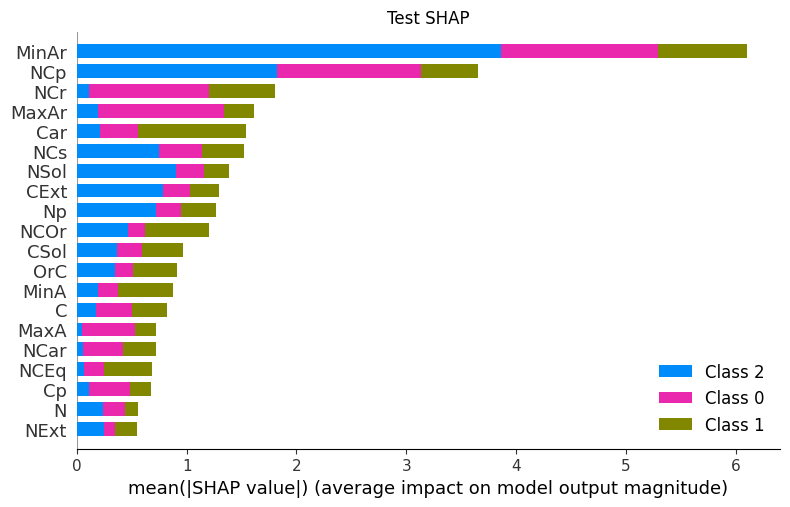

In [198]:
import shap


train_shap_values = shap.TreeExplainer(model_class["model"].named_steps["clf"]).shap_values(df_train.drop('class', axis=1))
test_shap_values = shap.TreeExplainer(model_class["model"].named_steps["clf"]).shap_values(X_test)

plt.subplot(2, 1, 1)
plt.title('Training SHAP')
shap.summary_plot(train_shap_values, df_train.drop('class', axis=1), plot_type="bar")

plt.subplot(2, 1, 2)
plt.title('Test SHAP')
shap.summary_plot(test_shap_values, X_test, plot_type="bar")

In [199]:
class_names = model_class["label_encoder"].classes_
print(class_names) 

['HSIL' 'LSIL' 'NSIL']


## LIME

In [203]:
import pandas as pd
import joblib
import numpy as np
from lime.lime_tabular import LimeTabularExplainer

model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models\best_model_LightGBM3.pkl")
label_encoder = model_class["label_encoder"]

TARGET = "class"
feature_names = list(df_train.drop(columns=[TARGET]).columns)

# 
X_train = df_train.drop(columns=[TARGET])
y_train = label_encoder.transform(df_train[TARGET])

df_test = df_test[df_test[TARGET].notna()].copy()
X_test = df_test.drop(columns=[TARGET])
y_test = label_encoder.transform(df_test[TARGET])

X_train_np = X_train.values
X_test_np  = X_test.values

explainer = LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=feature_names,
    class_names=list(label_encoder.classes_),
    mode="classification",
    random_state=42
)


predict_fn = lambda data: model_class["model"].predict_proba(
    pd.DataFrame(data, columns=feature_names)
)




In [204]:
features = {'N': np.uint64(4439), 'C': np.uint64(262118), 'NCr': np.float64(0.016935120823445927), 'Np': 277.49747383594513, 'Cp': 2309.796025156975, 'NCp': 0.12013938495590158, 'MinA': 73.0, 'MinAr': 0.12784588441331, 'MaxA': np.float64(83.35466393669883), 'MaxAr': np.float64(0.12441202480634707), 'Nar': 1.0405405405405406, 'Car': 1.0367132867132867, 'NCar': 1.0036917187001504, 'NExt': np.float64(0.7790452790452791), 'CExt': np.float64(0.772762650502954), 'NCExt': np.float64(1.008130088246677), 'NSol': np.float64(0.9855683836589698), 'CSol': np.float64(0.9516233848745476), 'NCs': np.float64(1.0356706227736272), 'EqN': np.float64(75.17918820444517), 'EqC': np.float64(577.7014825901795), 'NCEq': np.float64(0.13013500998365476), 'OrN': np.float64(1.446102061602086), 'OrC': np.float64(4.140502931377116), 'NCOr': np.float64(0.349257586715708)}
row = features.values()
row = np.array(list(row))
len(row)

25

In [205]:
model_class["model"].named_steps["clf"].predict_proba([row])

c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


array([[4.62623447e-06, 1.21527550e-04, 9.99873846e-01]])

In [206]:
exp = explainer.explain_instance(
    data_row=row,
    predict_fn=predict_fn, 
    top_labels=len(label_encoder.classes_))

exp.save_to_file("lime_explanation3.html")

## Uczenie z ograniczonymi cechami - bez skorelowanych 

In [ ]:
corr_matrix = df_train.drop(columns='class').corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

df_train_uncorr = df_train.drop(columns=to_drop)

print("Kolumny usunięte:", to_drop)
df_train_uncorr.head()

Kolumny usunięte: ['Np', 'NCp', 'MinA', 'MinAr', 'MaxA', 'MaxAr', 'NCExt', 'CSol', 'NCs', 'EqN', 'EqC', 'NCEq']


,N,C,NCr,Cp,Nar,Car,NCar,NExt,CExt,NSol,OrN,OrC,NCOr,class
0,6378,14898,0.428111,594.274166,0.429530,0.363265,1.182415,0.668834,0.683238,0.950168,-0.228032,-0.097290,2.343838,HSIL
1,6557,12602,0.520314,492.801077,1.123810,1.047619,1.072727,0.529217,0.556675,0.943385,5.439876,-4829.849982,-0.001126,HSIL
2,1353,3288,0.411496,298.409161,2.923077,2.837209,1.030265,0.684717,0.626763,1.009701,-0.342323,-0.492934,0.694461,HSIL
3,1357,2554,0.531323,233.078207,1.176471,0.972973,1.209150,0.443464,0.479354,0.991959,-3.104588,-9.747040,0.318516,HSIL
4,14851,41568,0.357270,913.879285,1.330882,0.976285,1.363211,0.603307,0.665184,0.922652,-2.107840,5.487555,-0.384113,HSIL


In [ ]:
df_train_uncorr.shape

(558, 14)

In [ ]:
df_train_uncorr.columns

Index(['N', 'C', 'NCr', 'Cp', 'Nar', 'Car', 'NCar', 'NExt', 'CExt', 'NSol',
       'OrN', 'OrC', 'NCOr', 'class'],
      dtype='object')

In [ ]:
df_test_uncorr = df_test.drop(columns=to_drop)
df_test_uncorr.shape

(103, 14)

In [ ]:
X_train, y_train = df_train_uncorr.drop(columns=["class"]), df_train_uncorr["class"]
X_test,  y_test  = df_test_uncorr.drop(columns=["class"]),  df_test_uncorr["class"]

In [ ]:
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

In [ ]:
import sklearn.metrics as M

results = []
for name, pipe in pipelines.items():
    print(f"\n=== GridSearch dla {name} ===")
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=2,
        refit=True  
    )
    grid.fit(X_train, y_train_enc)

    best_model = grid.best_estimator_
    best_params = grid.best_params_

    y_test_pred_enc = best_model.predict(X_test)
    y_test_pred = le.inverse_transform(y_test_pred_enc)

    results.append({
        "Model": name,
        "Split": "Test",
        "Best_Params": best_params,
        "Accuracy":  M.accuracy_score(y_test, y_test_pred),
        "Precision": M.precision_score(y_test, y_test_pred, average="macro", zero_division=0),
        "Recall":    M.recall_score(y_test, y_test_pred, average="macro", zero_division=0),
        "F1":        M.f1_score(y_test, y_test_pred, average="macro", zero_division=0)
    })

    joblib.dump({"model": best_model, "label_encoder": le}, f"models/best_model_{name}_uncorr.pkl")


results = pd.DataFrame(results).sort_values("F1", ascending=False)
print("\n=== Results ===")
print(results)



=== GridSearch dla SVM ===
Fitting 5 folds for each of 75 candidates, totalling 375 fits

=== GridSearch dla NeuralNet ===
Fitting 5 folds for each of 72 candidates, totalling 360 fits

=== GridSearch dla RandomForest ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits

=== GridSearch dla XGBoost ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits


c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:33:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== GridSearch dla LightGBM ===
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000272 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2555
[LightGBM] [Info] Number of data points in the train set: 624, number of used features: 13
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

In [ ]:
results

,Model,Split,Best_Params,Accuracy,Precision,Recall,F1
4,LightGBM,Test,"{'clf__colsample_bytree': 1.0, 'clf__learning_...",0.796117,0.788288,0.793210,0.789313
1,NeuralNet,Test,"{'clf__activation': 'relu', 'clf__alpha': 0.00...",0.776699,0.781011,0.774691,0.773894
2,RandomForest,Test,"{'clf__max_depth': 10, 'clf__min_samples_leaf'...",0.776699,0.768780,0.772531,0.768406
3,XGBoost,Test,"{'clf__colsample_bytree': 0.8, 'clf__learning_...",0.766990,0.766667,0.767284,0.762706
0,SVM,Test,"{'clf__C': 10, 'clf__gamma': 0.1, 'clf__kernel...",0.728155,0.723021,0.725926,0.723085


In [218]:
import os
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, precision_score, recall_score, f1_score, classification_report

y_true = []
y_pred = []
model_class = joblib.load(r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models\best_model_LightGBM3.pkl")
label_encoder = model_class["label_encoder"]
pipe = model_class["model"]
folder = r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\TEST'
for subfolder in os.listdir(folder):
    true_class = os.path.basename(subfolder)
    for filename in os.listdir(os.path.join(folder, subfolder)):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            image_path = os.path.join(folder, subfolder, filename)
            pil_image, input_tensor = preprocess_image(image_path)
            predicted_masks = predict_masks(model, input_tensor, device, threshold_nuclei=0.2, threshold_cell=0.5)
            cell_mask = predicted_masks[0]
            nucleus_mask = predicted_masks[1]
            features = extract_features(nucleus_mask, cell_mask)
            predicted_class = predict(pipe, label_encoder, input_features=features)
            y_true.append(true_class)
            y_pred.append(predicted_class)


acc = accuracy_score(y_true, y_pred)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
y_true, y_pred, labels=label_encoder.classes_, average="macro", zero_division=0
    )
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=label_encoder.classes_, average="weighted", zero_division=0
    )

print("\n=== METRYKI (global) ===")
print(f"Accuracy:            {acc:.4f}")
print(f"Precision (macro):   {prec_macro:.4f}")
print(f"Recall    (macro):   {rec_macro:.4f}")
print(f"F1        (macro):   {f1_macro:.4f}")
print(f"Precision (weighted):{prec_weighted:.4f}")
print(f"Recall    (weighted):{rec_weighted:.4f}")
print(f"F1        (weighted):{f1_weighted:.4f}")

print("\n=== RAPORT (per klasa) ===")
print(classification_report(y_true, y_pred, labels=label_encoder.classes_, digits=4))

cm = confusion_matrix(y_true, y_pred, labels=label_encoder.classes_, normalize='true')
cm_df = pd.DataFrame(
        cm,
        index=[f"true_{l}" for l in label_encoder.classes_],
        columns=[f"pred_{l}" for l in label_encoder.classes_],
    )
print("\n=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===")
print(cm_df)



fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_title("Confusion Matrix (HSIL/LSIL/NSIL, normalized)")
tick_marks = np.arange(len(label_encoder.classes_))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(label_encoder.classes_)
ax.set_yticklabels(label_encoder.classes_)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", color="black")

ax.set_ylabel("True class")
ax.set_xlabel("Predicted class")
fig.tight_layout()
plt.close()


=== METRYKI (global) ===
Accuracy:            0.6333
Precision (macro):   0.6583
Recall    (macro):   0.6333
F1        (macro):   0.6411
Precision (weighted):0.6583
Recall    (weighted):0.6333
F1        (weighted):0.6411

=== RAPORT (per klasa) ===
              precision    recall  f1-score   support

        HSIL     0.5000    0.6000    0.5455        10
        LSIL     0.6000    0.6000    0.6000        10
        NSIL     0.8750    0.7000    0.7778        10

    accuracy                         0.6333        30
   macro avg     0.6583    0.6333    0.6411        30
weighted avg     0.6583    0.6333    0.6411        30


=== CONFUSION MATRIX (znormalizowana, wartości 0–1) ===
           pred_HSIL  pred_LSIL  pred_NSIL
true_HSIL        0.6        0.4        0.0
true_LSIL        0.3        0.6        0.1
true_NSIL        0.3        0.0        0.7
